# Análisis de Incidentes de Ciberseguridad

Análisis exploratorio de un dataset de incidentes de ciberseguridad utilizando Python y herramientas de análisis de datos.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df_incidentes = pd.read_csv("../data/cybersecurity_dataset.csv")

## Exploración inicial

### Primeras filas

In [2]:
df_incidentes.head(10)

,Event ID,Timestamp,Source IP,Destination IP,User Agent,Attack Type,Attack Severity,Data Exfiltrated,Threat Intelligence,Response Action
0,2019969e-ecfa-41c4-b681-9b684bc3b3bf,2020-02-07 23:46:57,219.80.193.15,44.155.75.24,Mozilla/5.0 (Macintosh; PPC Mac OS X 10_7_8 rv...,Ransomware,Critical,False,Crime low this behind option tax product.,Eradicated
1,1668e954-781f-4731-94dc-24218b983ba1,2021-05-25 19:03:44,110.155.68.245,178.123.150.38,Mozilla/5.0 (Windows 95) AppleWebKit/534.2 (KH...,Malware,Critical,True,Responsibility work way effect.,Eradicated
2,0ef24a20-1d25-41fa-81b8-e19fb63e9e4c,2022-01-04 09:08:07,171.153.115.83,76.187.142.133,Mozilla/5.0 (X11; Linux x86_64; rv:1.9.7.20) G...,Ransomware,High,False,Artist though type imagine food push.,Eradicated
3,073b6225-0998-488c-aa1c-23e49814b6ff,2022-10-12 19:48:43,29.49.228.195,89.39.7.177,Mozilla/5.0 (Linux; Android 7.1.1) AppleWebKit...,DDoS,Critical,False,In still military despite TV look.,Contained
4,783fd153-6b88-44c1-8db5-d882300088cc,2021-11-24 02:04:33,120.43.64.52,113.82.34.164,Mozilla/5.0 (iPad; CPU iPad OS 9_3_6 like Mac ...,Malware,Medium,False,Push always least police it range either.,Eradicated
5,e3f69b23-e5d0-4a39-b894-ab87413a93b6,2022-06-11 02:11:58,114.170.234.8,36.246.60.2,Mozilla/5.0 (compatible; MSIE 9.0; Windows NT ...,Insider Threat,Medium,False,Enough trip successful total every.,Recovered
6,8b292334-60f6-4693-b563-39f399a4fae9,2020-08-24 18:30:46,212.62.126.191,31.113.210.1,Mozilla/5.0 (Windows CE; yi-US; rv:1.9.2.20) G...,DDoS,Medium,False,Form nothing new agree.,Recovered
7,36c0362b-2821-4e2b-bc6d-58bc3dcd5851,2022-03-31 20:12:23,24.171.248.77,9.122.217.42,Opera/9.14.(Windows NT 4.0; ayc-PE) Presto/2.9...,Insider Threat,Low,False,Require leg after school whom administration a...,Blocked
8,f2b68ec9-37f1-4c38-a9ba-37a630694893,2021-08-05 14:26:13,78.151.115.57,104.124.29.74,Mozilla/5.0 (Macintosh; U; Intel Mac OS X 10_1...,Malware,Medium,False,Parent stop attack by increase feel.,Blocked
9,9a0454f5-b7ad-4ed7-8001-6fd63a1d4709,2022-01-30 11:55:17,118.187.114.245,193.98.57.7,Mozilla/5.0 (X11; Linux x86_64; rv:1.9.6.20) G...,Ransomware,High,False,Article different oil investment maybe career.,Blocked


### Dimensiones del dataset

In [3]:
df_incidentes.shape

(20000, 10)

### Estructura y tipos de datos

In [4]:
df_incidentes.info()

<class 'pandas.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   Event ID             20000 non-null  str  
 1   Timestamp            20000 non-null  str  
 2   Source IP            20000 non-null  str  
 3   Destination IP       20000 non-null  str  
 4   User Agent           20000 non-null  str  
 5   Attack Type          20000 non-null  str  
 6   Attack Severity      20000 non-null  str  
 7   Data Exfiltrated     20000 non-null  bool 
 8   Threat Intelligence  20000 non-null  str  
 9   Response Action      20000 non-null  str  
dtypes: bool(1), str(9)
memory usage: 1.4 MB


### Valores nulos

In [5]:
df_incidentes.isnull().sum()

Event ID               0
Timestamp              0
Source IP              0
Destination IP         0
User Agent             0
Attack Type            0
Attack Severity        0
Data Exfiltrated       0
Threat Intelligence    0
Response Action        0
dtype: int64

### Registros duplicados

In [6]:
df_incidentes.duplicated().sum()

np.int64(0)

### Conocer los valores categóricos

In [7]:

print("Tipos de ataque:", df_incidentes["Attack Type"].unique())

print("Severidades:", df_incidentes["Attack Severity"].unique())

print("Acciones de respuesta:", df_incidentes["Response Action"].unique())


Tipos de ataque: <StringArray>
['Ransomware', 'Malware', 'DDoS', 'Insider Threat', 'Phishing']
Length: 5, dtype: str
Severidades: <StringArray>
['Critical', 'High', 'Medium', 'Low']
Length: 4, dtype: str
Acciones de respuesta: <StringArray>
['Eradicated', 'Contained', 'Recovered', 'Blocked']
Length: 4, dtype: str


### Exfiltración de datos

In [8]:
print("Datos extraidos: ", df_incidentes["Data Exfiltrated"].unique())

Datos extraidos:  [False  True]


### Inteligencia de amenazas

In [9]:
print("Ejemplos de inteligencia de amenazas:")
df_incidentes["Threat Intelligence"].head(5)

Ejemplos de inteligencia de amenazas:


0    Crime low this behind option tax product.
1              Responsibility work way effect.
2        Artist though type imagine food push.
3           In still military despite TV look.
4    Push always least police it range either.
Name: Threat Intelligence, dtype: str

### Conclusiones de la exploración inicial

- El dataset contiene 20.000 registros y 10 variables.
- No se encontraron valores nulos ni registros duplicados.
- Los incidentes se clasifican en 5 tipos de ataque y 4 niveles de severidad.
- La variable `Data Exfiltrated` indica si ocurrió exfiltración de datos mediante valores booleanos.
- `Timestamp` se encuentra almacenada como texto y deberá convertirse a formato de fecha y hora.
- `Threat Intelligence` contiene texto sintético sin información relevante para los objetivos del análisis, por lo que no será utilizada en los análisis principales.

## Limpieza y preparación

In [10]:
df_incidentes["Timestamp"] = pd.to_datetime(df_incidentes["Timestamp"])
df_incidentes["Year"] = df_incidentes["Timestamp"].dt.year
df_incidentes["Month"] = df_incidentes["Timestamp"].dt.month
df_incidentes["Day"] = df_incidentes["Timestamp"].dt.day
df_incidentes["Hour"] = df_incidentes["Timestamp"].dt.hour

### Comprobación

In [11]:
print(df_incidentes["Timestamp"].dtype)
print(df_incidentes["Year"].dtype)
print(df_incidentes["Month"].dtype)
print(df_incidentes["Day"].dtype)
print(df_incidentes["Hour"].dtype)

datetime64[us]
int32
int32
int32
int32


In [12]:
df_incidentes[["Timestamp", "Year", "Month", "Day", "Hour"]].head(5)

,Timestamp,Year,Month,Day,Hour
0,2020-02-07 23:46:57,2020,2,7,23
1,2021-05-25 19:03:44,2021,5,25,19
2,2022-01-04 09:08:07,2022,1,4,9
3,2022-10-12 19:48:43,2022,10,12,19
4,2021-11-24 02:04:33,2021,11,24,2


## Análisis general de incidentes.

In [13]:
total_incidentes = len(df_incidentes)

print(f"Total de incidentes: {total_incidentes}")

Total de incidentes: 20000


### Tipo de ataque más frecuente

In [14]:
conteo_ataques = df_incidentes["Attack Type"].value_counts()

print(conteo_ataques)

Attack Type
Malware           4081
Phishing          4056
Insider Threat    3968
Ransomware        3955
DDoS              3940
Name: count, dtype: int64


### Obtener automáticamente el más frecuente

In [15]:
ataque_mas_frecuente = conteo_ataques.idxmax()
cantidad_ataque_mas_frecuente = conteo_ataques[ataque_mas_frecuente]

print("Tipo de ataque más frecuente:", ataque_mas_frecuente)
print("Cantidad de incidentes:", cantidad_ataque_mas_frecuente)

Tipo de ataque más frecuente: Malware
Cantidad de incidentes: 4081


### Severidad de los incidentes

In [16]:
conteo_severidades =  df_incidentes["Attack Severity"].value_counts()
print(conteo_severidades)

Attack Severity
Low         5073
High        5053
Critical    5025
Medium      4849
Name: count, dtype: int64


### Severidad más frecuente

In [17]:
severidad_mas_frecuente = conteo_severidades.idxmax()
cantidad_severidad_mas_frecuente = conteo_severidades[severidad_mas_frecuente]

print(severidad_mas_frecuente)
print(cantidad_severidad_mas_frecuente)

Low
5073


### Acciones de respuesta

In [18]:
conteo_respuestas =  df_incidentes["Response Action"].value_counts()
print(conteo_respuestas)

Response Action
Eradicated    5063
Blocked       5020
Recovered     4980
Contained     4937
Name: count, dtype: int64


### Acción de respuesta más frecuente

In [19]:
respuesta_mas_frecuente = conteo_respuestas.idxmax()
cantidad_respuesta_mas_frecuente = conteo_respuestas[respuesta_mas_frecuente]

print(respuesta_mas_frecuente)
print(cantidad_respuesta_mas_frecuente) 


Eradicated
5063


## 6. Análisis de seguridad

En esta sección se analizan los incidentes desde una perspectiva de seguridad, relacionando niveles de severidad, exfiltración de datos, tipos de ataque e IPs involucradas.

### Incidentes críticos

In [20]:
mascara_criticos = (df_incidentes["Attack Severity"] == "Critical") 
incidentes_criticos = df_incidentes.loc[mascara_criticos]
cantidad_incidentes_criticos = len(incidentes_criticos)

print("Cantidad de incidentes críticos:", cantidad_incidentes_criticos)

Cantidad de incidentes críticos: 5025


### Exfiltración de datos

In [21]:
mascara_exfiltracion = (df_incidentes["Data Exfiltrated"] == True)
incidentes_exfiltracion = df_incidentes.loc[mascara_exfiltracion]
cantidad_exfiltracion = len(incidentes_exfiltracion)

porcentaje_exfiltracion = cantidad_exfiltracion / total_incidentes * 100

print("Cantidad de incidentes con exfiltración:", cantidad_exfiltracion)
print(f"Porcentaje de incidentes con exfiltración: {porcentaje_exfiltracion:.2f}%")

Cantidad de incidentes con exfiltración: 1919
Porcentaje de incidentes con exfiltración: 9.59%


### Exfiltración según severidad

In [22]:
severidad_exfiltracion = incidentes_exfiltracion["Attack Severity"].value_counts()
print(severidad_exfiltracion)

Attack Severity
Low         504
High        492
Critical    469
Medium      454
Name: count, dtype: int64


### Exfiltración según tipo de ataque

In [23]:
tipo_exfiltracion = incidentes_exfiltracion["Attack Type"].value_counts()
print(tipo_exfiltracion)

Attack Type
Malware           444
Phishing          377
DDoS              372
Ransomware        367
Insider Threat    359
Name: count, dtype: int64


### Tasa de exfiltración por tipo de ataque

In [24]:
porcentaje_exfiltracion_tipo = tipo_exfiltracion / conteo_ataques * 100

print(porcentaje_exfiltracion_tipo.round(2).astype(str) + "%")

Attack Type
DDoS               9.44%
Insider Threat     9.05%
Malware           10.88%
Phishing           9.29%
Ransomware         9.28%
Name: count, dtype: str


### Tasa de exfiltración por severidad

In [25]:
porcentaje_exfiltracion_severidad = severidad_exfiltracion / conteo_severidades * 100
print(porcentaje_exfiltracion_severidad.round(2).astype(str) + "%")

Attack Severity
Low         9.93%
High        9.74%
Critical    9.33%
Medium      9.36%
Name: count, dtype: str


### IPs de origen más frecuentes

In [26]:
conteo_ips_origen = df_incidentes["Source IP"].value_counts()

cantidad_ips_unicas = df_incidentes["Source IP"].nunique()

print(conteo_ips_origen.head(10))
print("Cantidad de IPs únicas:", cantidad_ips_unicas)


Source IP
219.80.193.15      1
110.155.68.245     1
171.153.115.83     1
29.49.228.195      1
120.43.64.52       1
114.170.234.8      1
212.62.126.191     1
24.171.248.77      1
78.151.115.57      1
118.187.114.245    1
Name: count, dtype: int64
Cantidad de IPs únicas: 20000


In [27]:
mascara_criticos_exfiltracion = (df_incidentes["Attack Severity"] == "Critical") & (df_incidentes["Data Exfiltrated"] == True)

incidentes_criticos_exfiltracion = df_incidentes.loc[mascara_criticos_exfiltracion]
cantidad_criticos_exfiltracion = len(incidentes_criticos_exfiltracion)

print("Cantidad de exfiltraciones criticas: ", cantidad_criticos_exfiltracion)


Cantidad de exfiltraciones criticas:  469


## Análisis temporal

En esta sección se analiza la distribución de los incidentes a lo largo del tiempo, considerando año, mes y hora, además de la evolución de los distintos tipos de ataque.

In [28]:
incidentes_por_año = df_incidentes["Year"].value_counts().sort_index()


fecha_inicio = df_incidentes["Timestamp"].min()
fecha_fin = df_incidentes["Timestamp"].max()


print(incidentes_por_año)

print(fecha_inicio)
print(fecha_fin)

Year
2020    4935
2021    4836
2022    4887
2023    4965
2024     377
Name: count, dtype: int64
2020-01-01 04:28:48
2024-01-30 05:23:34


### Incidentes por mes

In [29]:
incidentes_por_mes = df_incidentes["Month"].value_counts().sort_index()

print(incidentes_por_mes)

Month
1     2025
2     1554
3     1707
4     1617
5     1689
6     1587
7     1626
8     1689
9     1635
10    1645
11    1608
12    1618
Name: count, dtype: int64


### Incidentes por hora

In [30]:
incidentes_por_hora = df_incidentes["Hour"].value_counts().sort_index()

print(incidentes_por_hora)

Hour
0     841
1     842
2     833
3     829
4     782
5     826
6     841
7     832
8     802
9     833
10    807
11    834
12    813
13    847
14    818
15    882
16    881
17    833
18    835
19    870
20    826
21    830
22    857
23    806
Name: count, dtype: int64


### Evolución de los tipos de ataque por año

In [31]:
ataques_por_año = df_incidentes.groupby(["Year", "Attack Type"]).size().unstack()

print(ataques_por_año)

Attack Type  DDoS  Insider Threat  Malware  Phishing  Ransomware
Year                                                            
2020          994             945      988      1002        1006
2021          908             996     1007      1004         921
2022          971             977     1021       952         966
2023          992             969      982      1019        1003
2024           75              81       83        79          59


## Visualización de datos

### Distribución por tipo de ataque

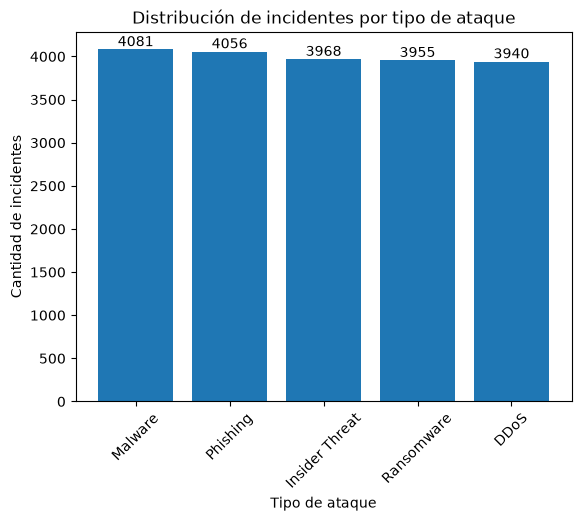

In [32]:
plt.bar(conteo_ataques.index, conteo_ataques.values)

plt.title("Distribución de incidentes por tipo de ataque")
plt.xlabel("Tipo de ataque")
plt.ylabel("Cantidad de incidentes")
plt.xticks(rotation=45)

for i, valor in enumerate(conteo_ataques.values):
    plt.text(i, valor, str(valor), ha="center", va="bottom")

plt.show()

### Distribución por severidad

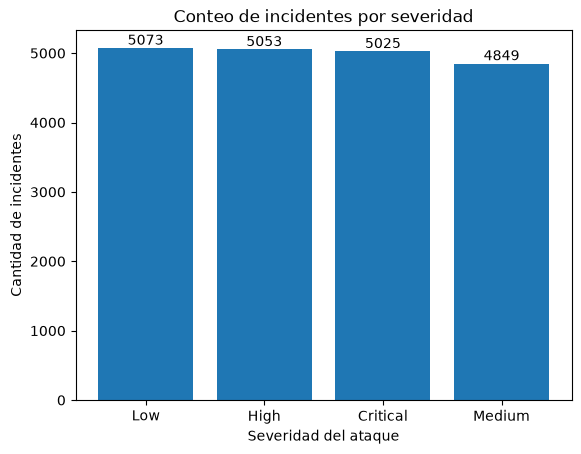

In [33]:
plt.bar(conteo_severidades.index, conteo_severidades.values)

plt.title("Conteo de incidentes por severidad")

plt.xlabel("Severidad del ataque")
plt.ylabel("Cantidad de incidentes")

for i, valor in enumerate(conteo_severidades.values):
    plt.text(i, valor, str(valor), ha="center", va="bottom")

plt.show()

### Tasa de exfiltración por tipo de ataque

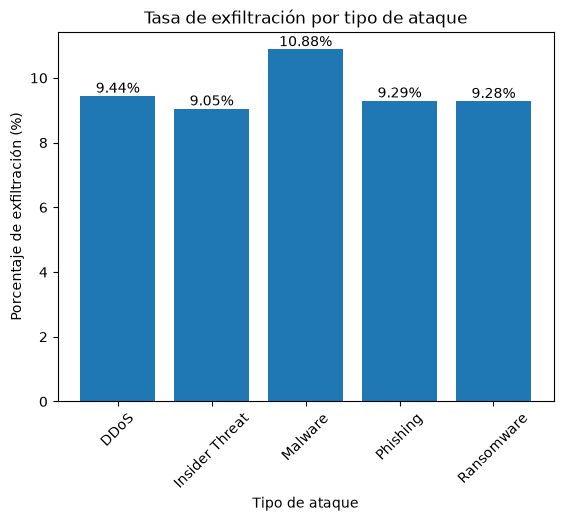

In [34]:
plt.bar(porcentaje_exfiltracion_tipo.index, porcentaje_exfiltracion_tipo.values)

plt.title("Tasa de exfiltración por tipo de ataque")

plt.xlabel("Tipo de ataque")
plt.ylabel("Porcentaje de exfiltración (%)")
plt.xticks(rotation=45)

for i, valor in enumerate(porcentaje_exfiltracion_tipo.values):
    plt.text(i, valor, f"{valor:.2f}%", ha="center", va="bottom")

plt.show()


### Incidentes por hora

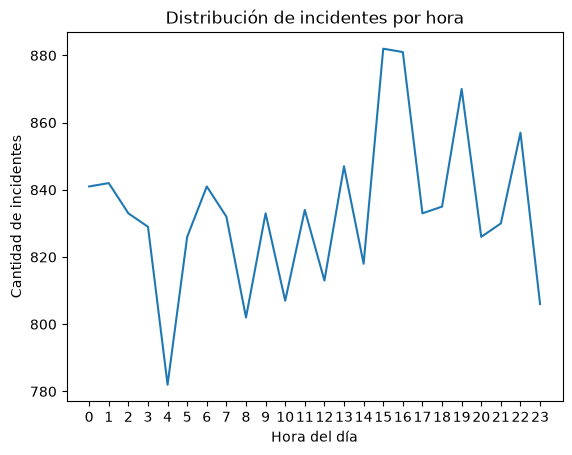

In [35]:
plt.plot(
    incidentes_por_hora.index,
    incidentes_por_hora.values  
)

plt.title("Distribución de incidentes por hora")
plt.xlabel("Hora del día")
plt.ylabel("Cantidad de incidentes")
plt.xticks(range(24))

plt.show()

### Evolución de tipos de ataque por año

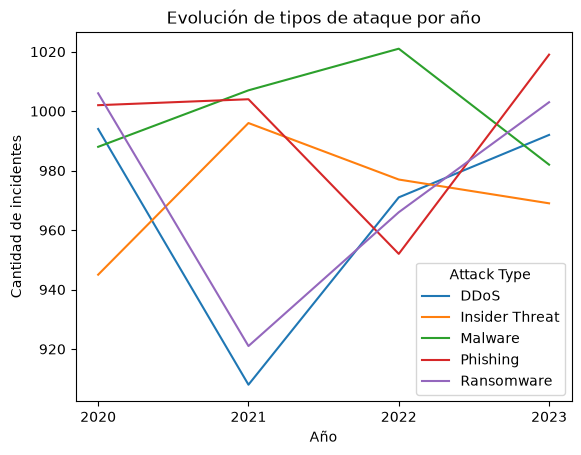

In [36]:
ataques_por_año.loc[2020:2023].plot()

plt.title("Evolución de tipos de ataque por año")
plt.xlabel("Año")
plt.ylabel("Cantidad de incidentes")

plt.xticks([2020, 2021, 2022, 2023])

plt.show()

## Análisis de relaciones entre variables

### Tipo de ataque vs severidad

In [37]:
ataques_por_severidad = df_incidentes.groupby(["Attack Type", "Attack Severity"]).size().unstack()

print(ataques_por_severidad)

Attack Severity  Critical  High   Low  Medium
Attack Type                                  
DDoS                  981  1019  1030     910
Insider Threat       1020   996  1010     942
Malware               995  1078  1026     982
Phishing             1031  1002  1021    1002
Ransomware            998   958   986    1013


### Tipo de ataque vs acción de respuesta

In [38]:
ataques_por_respuesta = df_incidentes.groupby(["Attack Type", "Response Action"]).size().unstack()

print(ataques_por_respuesta)

Response Action  Blocked  Contained  Eradicated  Recovered
Attack Type                                               
DDoS                1016        968         980        976
Insider Threat       967        977        1052        972
Malware             1050       1024        1026        981
Phishing             999       1013        1024       1020
Ransomware           988        955         981       1031


### Severidad vs acción de respuesta

In [39]:
respuestas_por_severidad = df_incidentes.groupby(["Attack Severity", "Response Action"]).size().unstack()

print(respuestas_por_severidad)



Response Action  Blocked  Contained  Eradicated  Recovered
Attack Severity                                           
Critical            1226       1272        1278       1249
High                1269       1268        1262       1254
Low                 1301       1229        1284       1259
Medium              1224       1168        1239       1218


### Exfiltración según tipo de ataque y severidad

In [40]:
exfiltracion_tipo_severidad = incidentes_exfiltracion.groupby(["Attack Type", "Attack Severity"]).size().unstack()

print(exfiltracion_tipo_severidad)

Attack Severity  Critical  High  Low  Medium
Attack Type                                 
DDoS                   92    96  100      84
Insider Threat         86    76  101      96
Malware                97   124  114     109
Phishing              102    99   86      90
Ransomware             92    97  103      75


## Análisis de User Agent

### Explorar los User Agents

In [41]:
cantidad_user_agents = df_incidentes["User Agent"].nunique()

print("Cantidad de User Agents únicos:", cantidad_user_agents)

df_incidentes["User Agent"].head(10)

Cantidad de User Agents únicos: 16327


0    Mozilla/5.0 (Macintosh; PPC Mac OS X 10_7_8 rv...
1    Mozilla/5.0 (Windows 95) AppleWebKit/534.2 (KH...
2    Mozilla/5.0 (X11; Linux x86_64; rv:1.9.7.20) G...
3    Mozilla/5.0 (Linux; Android 7.1.1) AppleWebKit...
4    Mozilla/5.0 (iPad; CPU iPad OS 9_3_6 like Mac ...
5    Mozilla/5.0 (compatible; MSIE 9.0; Windows NT ...
6    Mozilla/5.0 (Windows CE; yi-US; rv:1.9.2.20) G...
7    Opera/9.14.(Windows NT 4.0; ayc-PE) Presto/2.9...
8    Mozilla/5.0 (Macintosh; U; Intel Mac OS X 10_1...
9    Mozilla/5.0 (X11; Linux x86_64; rv:1.9.6.20) G...
Name: User Agent, dtype: str

### Identificar plataforma desde User Agent

In [42]:
mascara_windows = df_incidentes["User Agent"].str.contains("Windows")
mascara_mac = df_incidentes["User Agent"].str.contains("Macintosh")
mascara_iphone = df_incidentes["User Agent"].str.contains("iPhone")
mascara_ipad = df_incidentes["User Agent"].str.contains("iPad")


# Windows

incidentes_windows = df_incidentes.loc[mascara_windows]
cantidad_windows= len(incidentes_windows)

print("Cantidad Windows:", cantidad_windows)


# Linux

mascara_linux = (
    df_incidentes["User Agent"].str.contains("Linux")
    & ~df_incidentes["User Agent"].str.contains("Android")
)

incidentes_linux = df_incidentes.loc[mascara_linux]
cantidad_linux = len(incidentes_linux)

print("Cantidad Linux:", cantidad_linux)


# Android

mascara_android = df_incidentes["User Agent"].str.contains("Android")

incidentes_android = df_incidentes.loc[mascara_android]
cantidad_android = len(incidentes_android)

print("Cantidad Android:", cantidad_android)


# Mac

incidentes_mac = df_incidentes.loc[mascara_mac]
cantidad_mac= len(incidentes_mac)

print("Cantidad Mac:", cantidad_mac)


# iPhone

incidentes_iphone = df_incidentes.loc[mascara_iphone]
cantidad_iphone= len(incidentes_iphone)

print("Cantidad Iphone:", cantidad_iphone)



# iPad

incidentes_ipad = df_incidentes.loc[mascara_ipad]
cantidad_ipad= len(incidentes_ipad)

print("Cantidad Ipad:", cantidad_ipad)


total_cantidades = sum([
    cantidad_windows,
    cantidad_linux,
    cantidad_android,
    cantidad_mac,
    cantidad_iphone,
    cantidad_ipad
])

print("Total de incidentes:", total_cantidades)

Cantidad Windows: 8916
Cantidad Linux: 3633
Cantidad Android: 1611
Cantidad Mac: 2901
Cantidad Iphone: 2128
Cantidad Ipad: 811
Total de incidentes: 20000


### Resumen por plataforma

In [43]:
plataformas = pd.Series({
    "Windows": cantidad_windows,
    "Linux": cantidad_linux,
    "Android": cantidad_android,
    "Mac": cantidad_mac,
    "iPhone": cantidad_iphone,
    "iPad": cantidad_ipad
})

porcentaje_plataformas = plataformas / total_cantidades * 100

print(porcentaje_plataformas.round(2).astype(str) + "%")

Windows    44.58%
Linux      18.16%
Android     8.06%
Mac         14.5%
iPhone     10.64%
iPad        4.06%
dtype: str


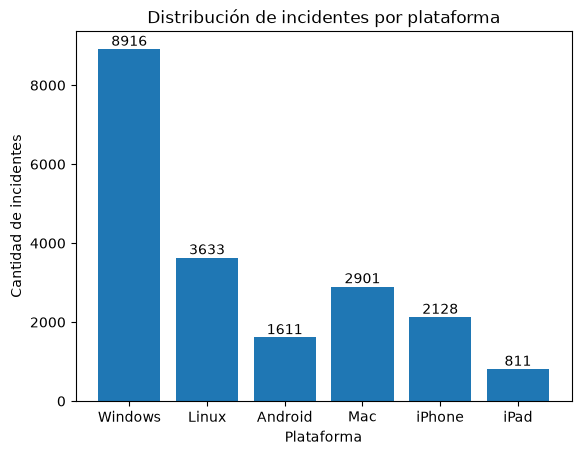

In [44]:
plt.bar(plataformas.index,
        plataformas.values
)

plt.title("Distribución de incidentes por plataforma")
plt.xlabel("Plataforma")
plt.ylabel("Cantidad de incidentes")

for i, valor in enumerate(plataformas.values):
    plt.text(i, valor, str(valor), ha="center", va="bottom")

plt.show()

## Conclusiones y hallazgos

El análisis de los 20.000 incidentes permitió identificar los siguientes hallazgos principales:

- **Malware** fue el tipo de ataque más frecuente, con **4.081 incidentes**, aunque la distribución entre los distintos tipos de ataque fue relativamente equilibrada.
- La severidad más frecuente fue **Low**, con **5.073 incidentes**, seguida muy de cerca por High y Critical.
- Se registraron **1.919 incidentes con exfiltración de datos**, equivalentes al **9,59 %** del total.
- **Malware presentó la mayor tasa de exfiltración**, con aproximadamente **10,88 %** de sus incidentes.
- Entre los incidentes con exfiltración, la combinación más frecuente fue **Malware de severidad High**, con **124 casos**.
- La acción de respuesta más frecuente fue **Eradicated**, con **5.063 incidentes**.
- Entre 2020 y 2023 no se observó una tendencia sostenida de crecimiento o disminución en los tipos de ataque, sino variaciones relativamente moderadas entre años.
- Los datos de 2024 no fueron utilizados para comparar tendencias anuales debido a que el dataset solamente contiene registros hasta el **30 de enero de 2024**.
- En los User Agents analizados, **Windows fue la plataforma más frecuente**, representando aproximadamente el **44,58 %** de los registros.

En general, el dataset presenta una distribución bastante equilibrada entre tipos de ataque, severidades y acciones de respuesta. El análisis permitió aplicar técnicas de limpieza, filtrado, agrupación, análisis temporal, cruces entre variables y visualización de datos utilizando Python, Pandas y Matplotlib.